In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

In [3]:
df  = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Data sets\students (1).csv")

In [5]:
df.head()

,cgpa,iq,attendance,placement
0,3.28,73,97,Yes
1,2.55,98,58,No
2,3.47,139,55,Yes
3,3.18,74,51,No
4,2.19,99,82,No


In [6]:
df.isnull().sum()

cgpa          0
iq            0
attendance    0
placement     0
dtype: int64

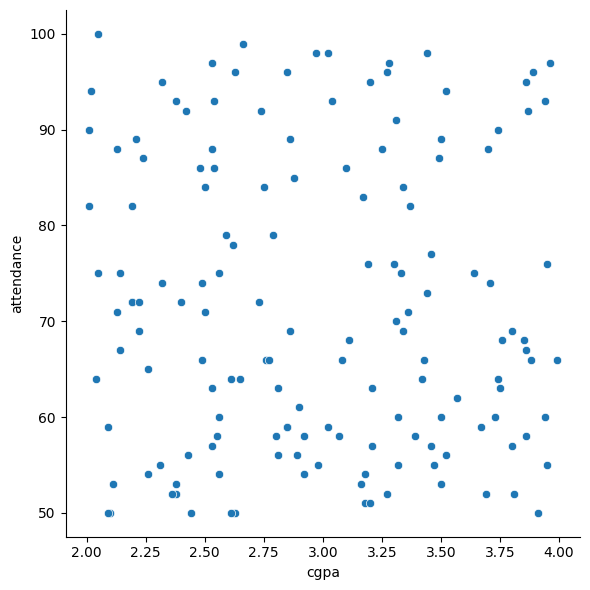

In [24]:
sns.relplot(data = df , x= "cgpa" , y = "attendance" , kind = "scatter" , height = 6)

In [12]:
df.describe()

,cgpa,iq,attendance
count,150.000000,150.000000,150.000000
mean,2.971200,107.593333,71.513333
std,0.581776,21.472660,15.188187
min,2.010000,70.000000,50.000000
25%,2.500000,90.000000,58.000000
50%,2.920000,105.000000,69.000000
75%,3.440000,127.750000,86.000000
max,3.990000,140.000000,100.000000


<Axes: xlabel='placement'>

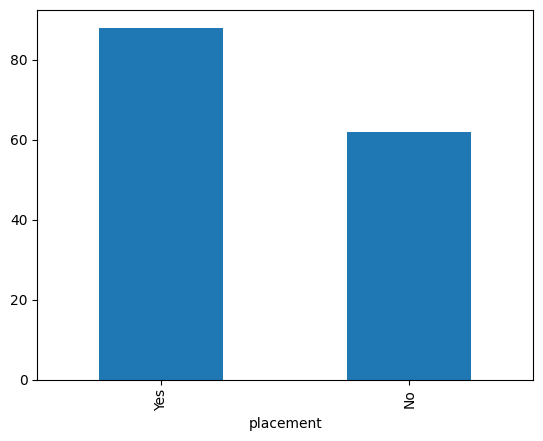

In [14]:
df["placement"].value_counts().plot(kind = "bar")

In [15]:
df.head()

,cgpa,iq,attendance,placement
0,3.28,73,97,Yes
1,2.55,98,58,No
2,3.47,139,55,Yes
3,3.18,74,51,No
4,2.19,99,82,No


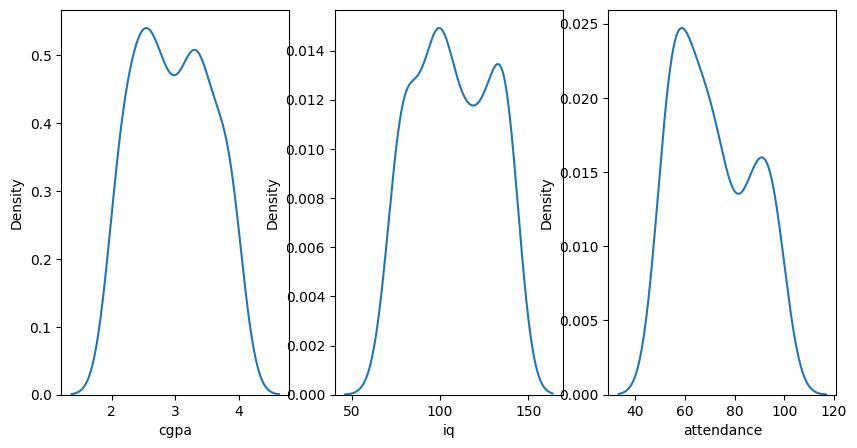

In [21]:
plt.figure(figsize = (10,5))
plt.subplot(1,3,1)
sns.kdeplot(df["cgpa"])

plt.subplot(1,3,2)
sns.kdeplot(df["iq"])

plt.subplot(1,3,3)
sns.kdeplot(df["attendance"])
plt.show()

In [52]:
X = df["Placement"]

In [54]:
df.drop(columns = ["Placement"], inplace = True)

In [55]:
df["Performance"] = np.random.choice(["Poor" , "Good" , "Best"] , 150)
df["City"] = np.random.choice(["Karachi" , "Lahore" , "Multan"] , 150)

In [56]:
df["Placement"] = X

In [57]:
df.head(2)

,cgpa,iq,attendance,Performance,City,Placement
0,3.28,73,97,Best,Multan,Yes
1,2.55,98,58,Good,Lahore,No


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import OrdinalEncoder 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler

In [58]:
X = df.iloc[:, 0:5]
y = df.iloc[:,5]

In [59]:
X_train , X_test , y_train , y_test  = train_test_split(X, y , test_size = 0.25 , random_state = 42)

In [73]:
transformer = ColumnTransformer(transformers=[
("First" , StandardScaler() , ["cgpa" , "iq" , "attendance"]),
("Second" , OrdinalEncoder(categories = [["Poor" , "Good" , "Best"]]), ["Performance"]),
("Third" , OneHotEncoder(drop = "first" , sparse_output = False) , ["City"])
    
], remainder = "passthrough")

In [74]:
transformer.fit_transform(X_train)

array([[-1.29525367e+00, -3.31850074e-01,  6.90417476e-01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 8.91791839e-01,  8.26728737e-01,  1.00475389e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 8.07674704e-01, -5.17222683e-01,  1.24611935e-01,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 3.36618749e-01,  1.52187602e+00, -1.13273371e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 9.08615266e-01, -1.35139943e+00, -1.13273371e+00,
         2.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-9.75608555e-01, -1.30505627e+00, -1.19560099e+00,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-8.91491420e-01,  3.16954060e-01, -9.44131866e-01,
         2.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-3.36318330e-01,  5.95012975e-01, -3.15459042e-01,
         1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 6.73087288e-01,  1.47553287e+00, -1.122